In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.inst.isoplane import (
    convert_isoplane_header,
    add_fiber_table,
    write_isoplane_converted_image,
)
from kspecdr.io.image import ImageFile
from kspecdr.preproc.make_im import make_im
from kspecdr.preproc.preproc import reduce_bias, reduce_dark, combine_image
from kspecdr.tlm.make_tlm import read_instrument_data, make_tlm
from kspecdr.extract.make_ex import make_ex
from kspecdr.extract.reduce_arc import reduce_arcs, reduce_arc
from scipy.signal import find_peaks_cwt, find_peaks
from rascal.util import refine_peaks
from matplotlib.lines import Line2D
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path("/data1/hbahk/kspec/kspecdr")
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "isoplane_commissioning" / "dark" / "260121"

In [4]:
logging.getLogger("kspecdr.io.image").setLevel(logging.WARNING)
bias_files = list(TESTDIR.glob("bias*.fits"))
bias_files_converted = [TESTDIR / f.name.replace("bias", "cbias") for f in bias_files]

for bfpath, bfpath_converted in zip(bias_files, bias_files_converted):
    write_isoplane_converted_image(bfpath, bfpath_converted, "BIAS", n_fibers=14)

mbias_path = TESTDIR / "mbias.fits"
mbias_file = reduce_bias(bias_files_converted, output_file=mbias_path.as_posix())

2026-01-30 22:13:36,629 | kspecdr.inst.isoplane | INFO | Readout settings: speed=2 MHz, gain=HIGH, noise=LOW
2026-01-30 22:13:36,641 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-30 22:13:36,692 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 22:13:36,699 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 22:13:36,725 | kspecdr.inst.isoplane | INFO | Readout settings: speed=2 MHz, gain=HIGH, noise=LOW
2026-01-30 22:13:36,728 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 22:13:36,735 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 22:13:36,763 | kspecdr.inst.isoplane | INFO | Readout settings: speed=2 MHz, gain=HIGH, noise=LOW
2026-01-30 22:13:36,765 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 22:13:36,771 | kspecdr.inst.isoplane | INFO | Flipped verti

In [ ]:
dark_files = list(TESTDIR.glob("dark*.fits"))
dark_files_converted = [TESTDIR / f.name.replace("dark", "cdark") for f in dark_files]

for dfpath, dfpath_converted in zip(dark_files, dark_files_converted):
    write_isoplane_converted_image(dfpath, dfpath_converted, "DARK", n_fibers=14)
    
    make_im(
        dfpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )

2026-01-30 22:14:33,235 | kspecdr.inst.isoplane | INFO | Readout settings: speed=2 MHz, gain=HIGH, noise=LOW
2026-01-30 22:14:33,246 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-01-30 22:14:33,248 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-01-30 22:14:33,255 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-01-30 22:14:33,269 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-01-30 22:14:33,269 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_5min_00001.fits -> /data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_5min_00001_im.fits
2026-01-30 22:14:33,273 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS: , BITPIX: 16
2026-01-30 22:14:33,2

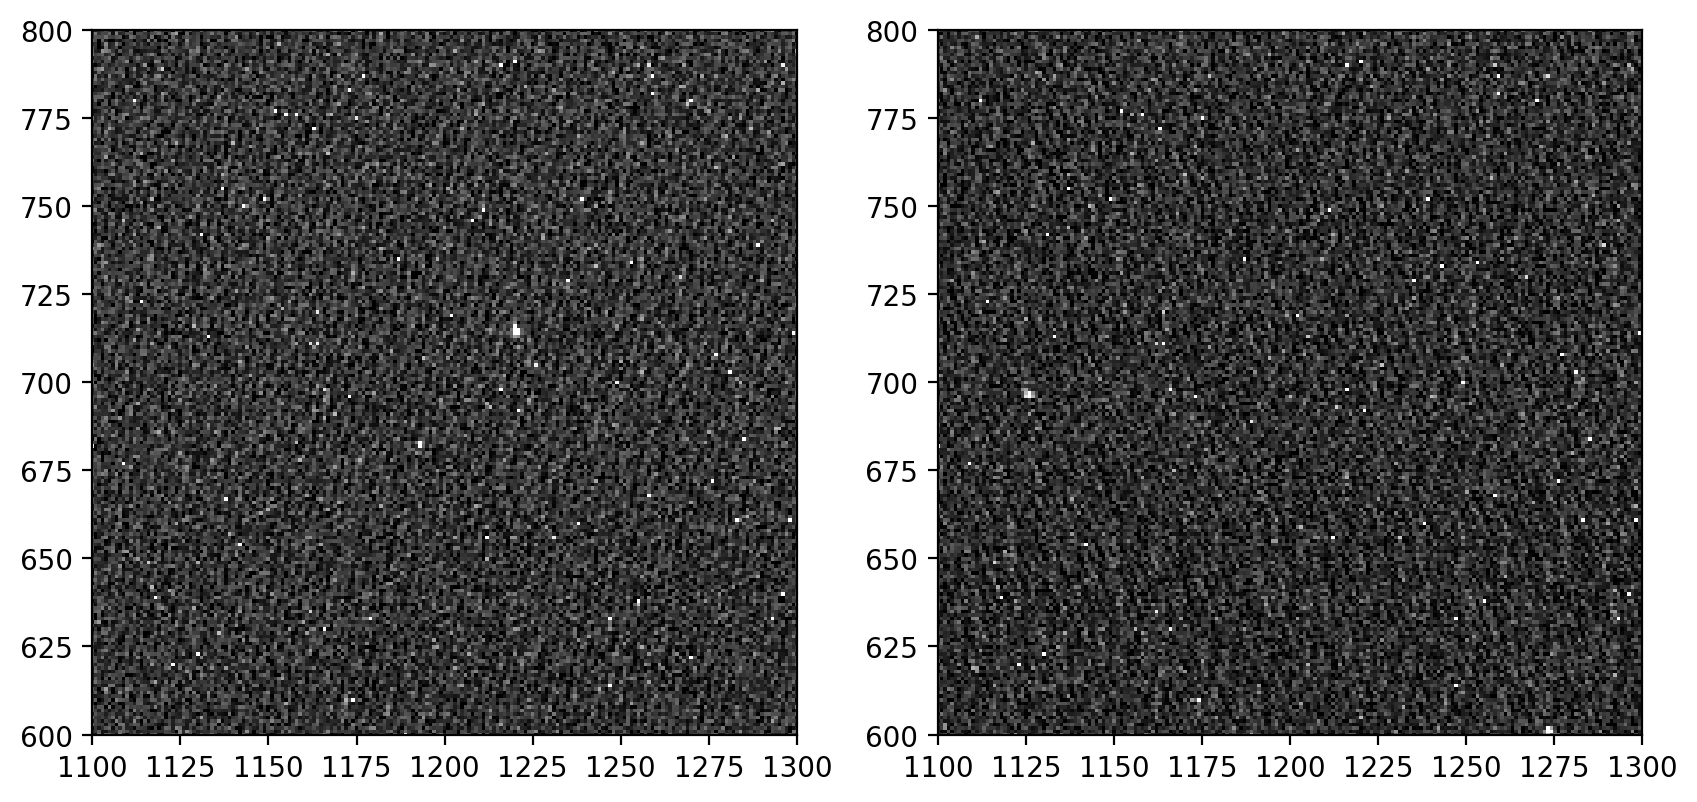

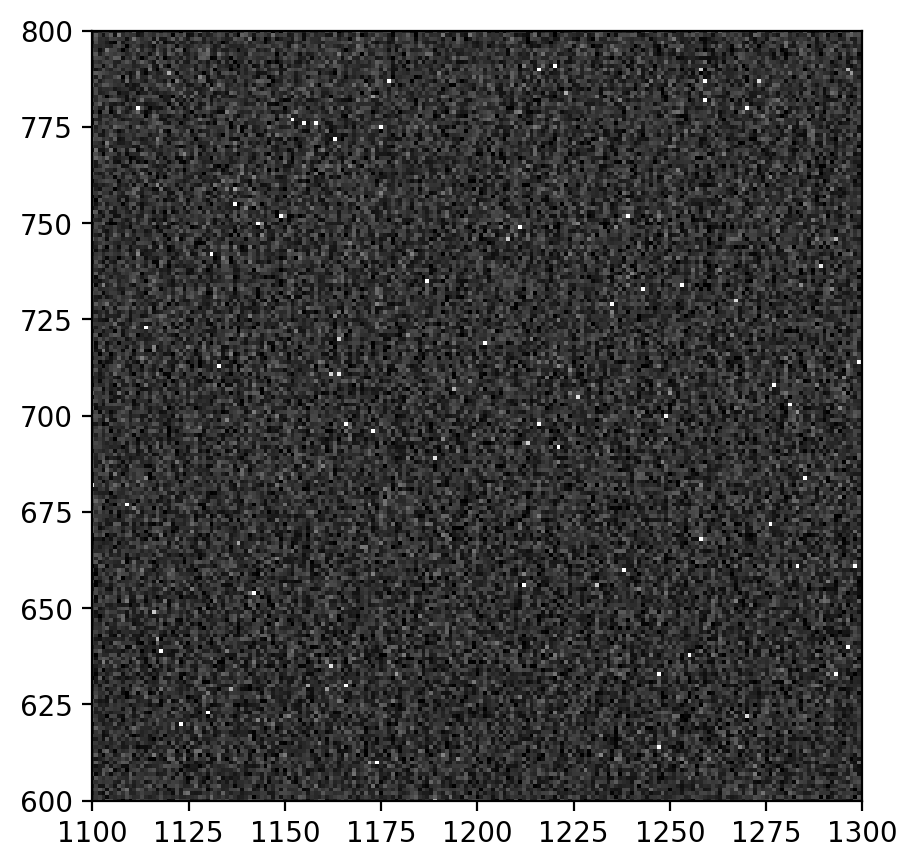

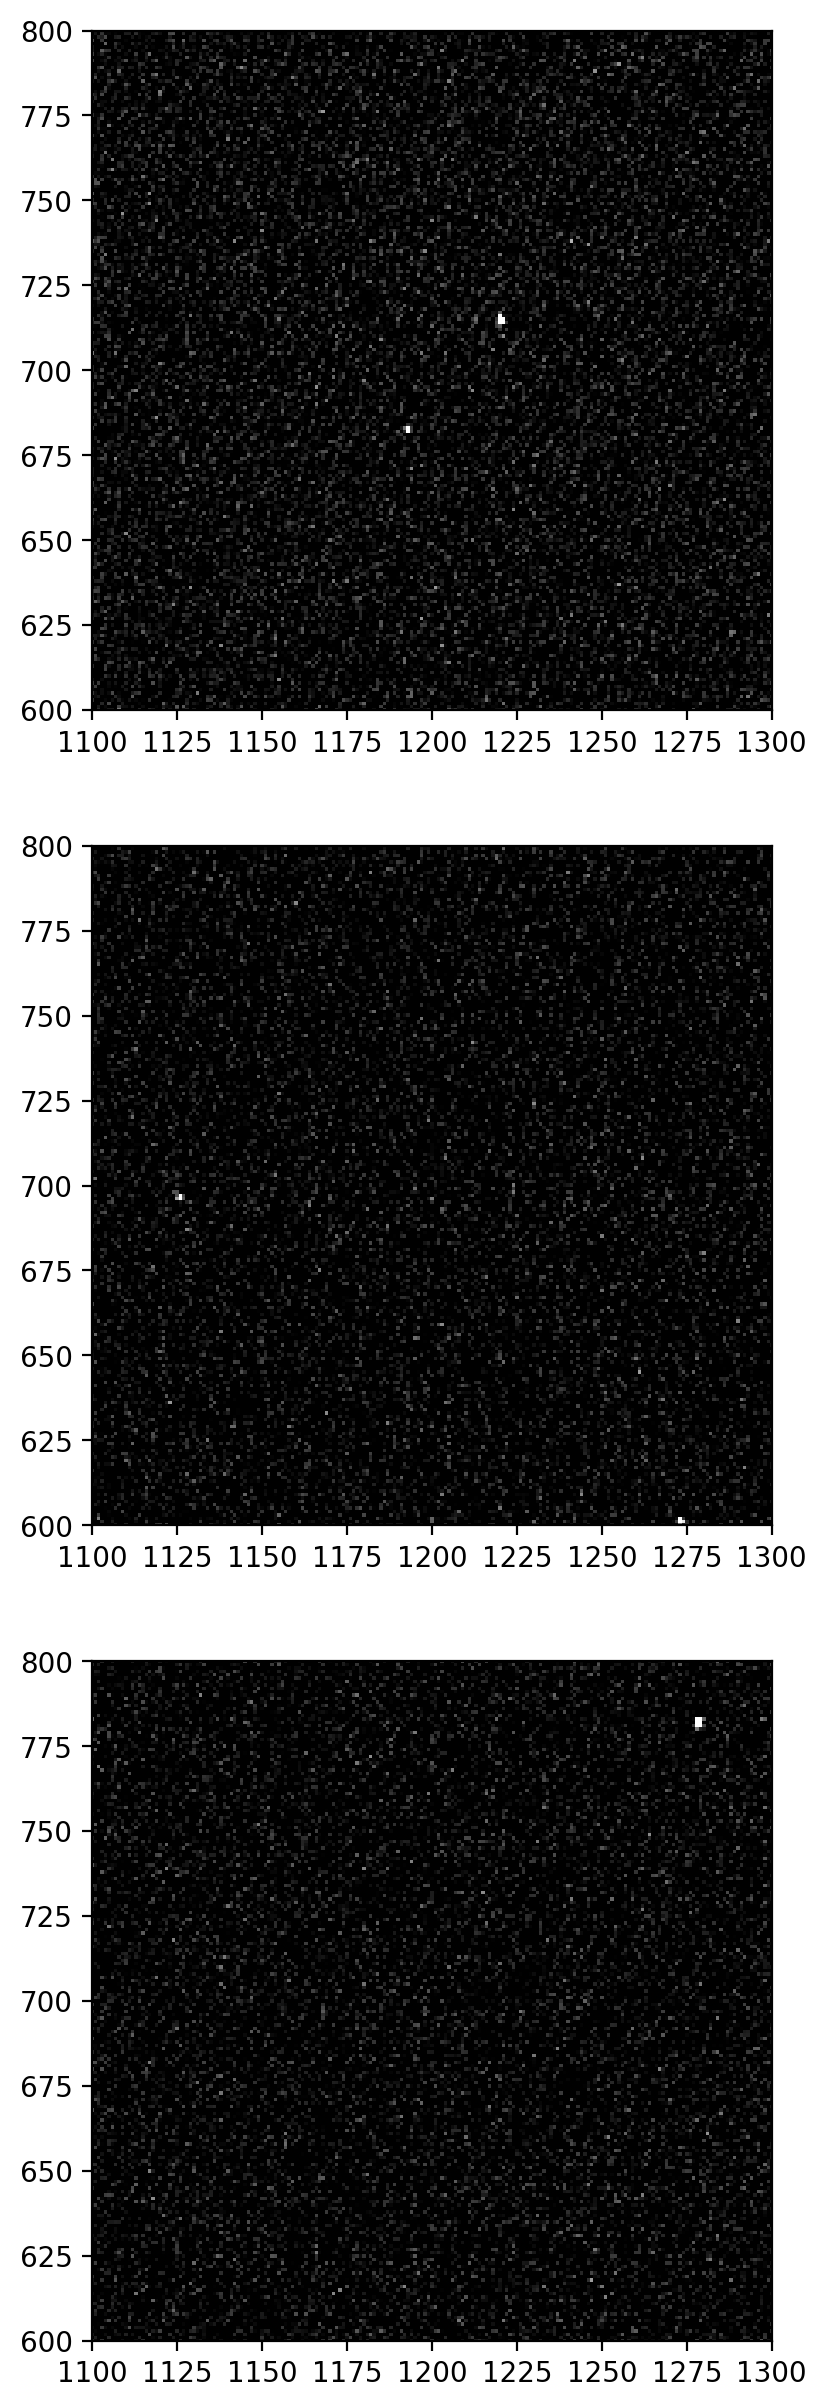

In [15]:
hdul = fits.open(TESTDIR / (dark_files_converted[3].stem + "_im.fits"))

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121)
ax.imshow(hdul[0].data, cmap='gray', origin='lower', vmin=0, vmax=100)
ax.set_xlim(1100, 1300)
ax.set_ylim(600, 800)

hdul = fits.open(TESTDIR / (dark_files_converted[4].stem + "_im.fits"))

ax = fig.add_subplot(122)
ax.imshow(hdul[0].data, cmap='gray', origin='lower', vmin=0, vmax=100)
ax.set_xlim(1100, 1300)
ax.set_ylim(600, 800)
plt.show()

imglist = []
for i in [3,4,5]:
    hdul = fits.open(TESTDIR / (dark_files_converted[i].stem + "_im.fits"))
    imglist.append(hdul[0].data)
    
img = np.median(imglist, axis=0)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray', origin='lower', vmin=0, vmax=100)
ax.set_xlim(1100, 1300)
ax.set_ylim(600, 800)
plt.show()

fig = plt.figure(figsize=(5, 15))
for i in [3,4,5]:
    hdul = fits.open(TESTDIR / (dark_files_converted[i].stem + "_im.fits"))
    ax = fig.add_subplot(3, 1, i-2)
    ax.imshow(hdul[0].data - img, cmap='gray', origin='lower', vmin=0, vmax=100)
    ax.set_xlim(1100, 1300)
    ax.set_ylim(600, 800)
plt.show()





(600.0, 800.0)

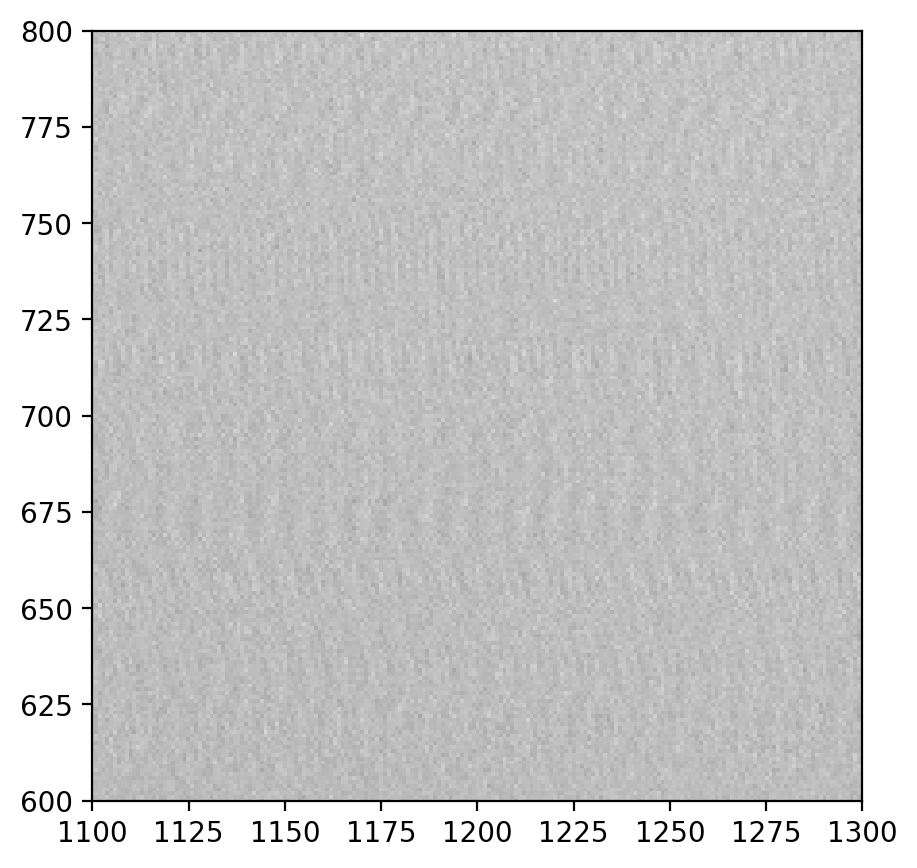

In [17]:
mbias_data = fits.getdata(mbias_path)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.imshow(mbias_data, cmap='gray', origin='lower')
ax.set_xlim(1100, 1300)
ax.set_ylim(600, 800)

In [30]:
dark_files_converted

[PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_5min_00001.fits'),
 PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_5min_00002.fits'),
 PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_5min_00003.fits'),
 PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_10min_00001.fits'),
 PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_10min_00002.fits'),
 PosixPath('/data1/hbahk/kspec/kspecdr/resources/isoplane_commissioning/dark/260121/cdark_10min_00003.fits')]

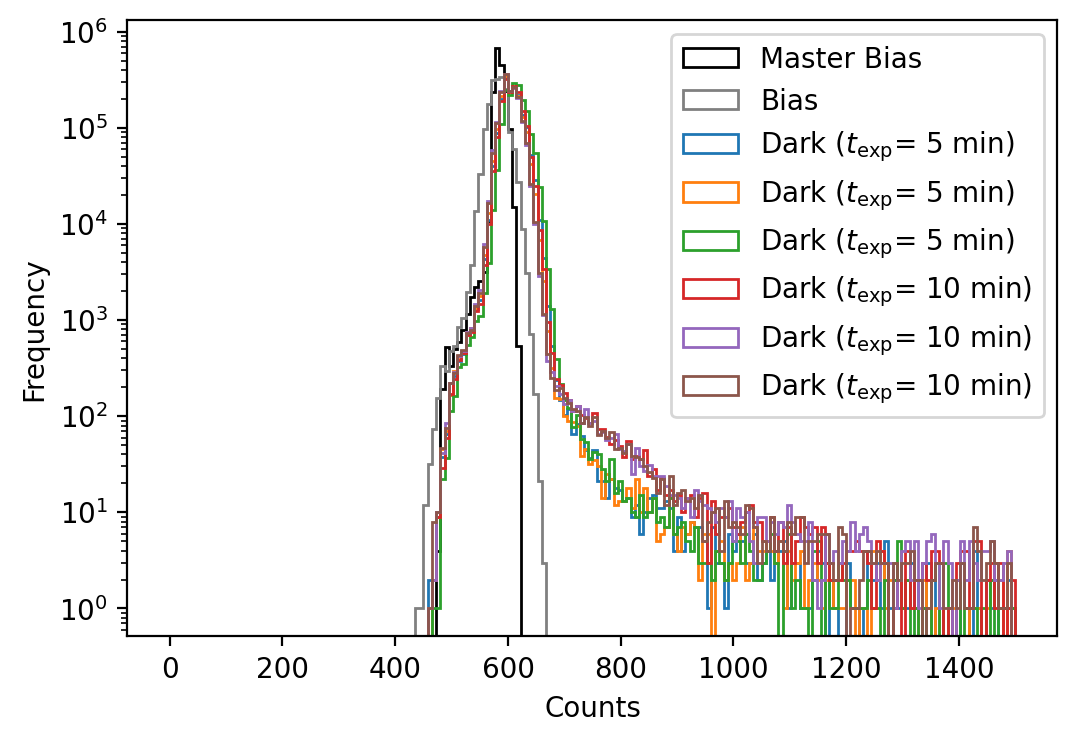

In [40]:
# histogram of the bias image
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.hist(mbias_data.flatten(), bins=200, color='black', histtype='step', label="Master Bias", range=(0, 1500))
ax.set_xlabel("Counts")
ax.set_ylabel("Frequency")
ax.legend()

bias_data = fits.getdata(bias_files_converted[0])
ax.hist(bias_data.flatten(), bins=200, color='gray', histtype='step', label="Bias", range=(0, 1500))

for dark_file in dark_files_converted:
    dark_data = fits.getdata(dark_file)
    header = fits.getheader(dark_file)
    exposure_time = float(header['EXPTIME'])/1000/60
    label = r"Dark ($t_{\rm exp}$= "+f"{exposure_time:.0f} min)"
    ax.hist(dark_data.flatten(), bins=200, histtype='step', label=label, range=(0, 1500))
    
ax.set_yscale('log')
ax.legend()
plt.show()

